<a href="https://colab.research.google.com/github/sandip-thakuri01/Data-Science-Projects/blob/main/frauddet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df_account = pd.read_csv('/content/account_profiles.csv')
df_pattern = pd.read_csv('/content/fraud_patterns.csv')
df_network = pd.read_csv('/content/network_edges.csv')
df_time = pd.read_csv('/content/time_series_stats.csv')
df_trans = pd.read_csv('/content/transactions.csv')

In [ ]:
COLORS = {"fraud": "#E63946", "legit": "#457B9D", "warning": "#FFC107"}

### Exploring `df_account`

In [ ]:
print (' Head of df_account ')
display(df_account.head())

print('\nSummary Info of df_account ')
df_account.info()

print('\n Duplicates in df_account ')
display(df_account.duplicated().sum())

print('\n Missing Values in df_account ')
display(df_account.isnull().sum())

 Head of df_account 


,account_id,account_age_days,credit_limit,home_country,risk_score,is_high_risk,avg_txn_amount,avg_monthly_txns,has_2fa,account_type,...,max_amount,fraud_count,fraud_amount,pct_foreign,avg_velocity,unique_countries,unique_categories,avg_ip_risk,fraud_rate,is_fraudster
0,ACC0000001,353,2171.42,US,16.5,0,90.82,71.1,1,personal,...,740.46,0.0,0.00,0.35,1.27,9.0,11.0,22.98,0.0,0.0
1,ACC0000002,2831,3031.38,US,25.4,0,63.78,7.4,1,business,...,186.13,1.0,186.13,0.50,4.00,2.0,2.0,52.45,0.5,1.0
2,ACC0000003,2399,7533.75,US,10.6,0,72.18,31.9,0,personal,...,1175.86,0.0,0.00,0.17,1.44,3.0,8.0,15.50,0.0,0.0
3,ACC0000004,1618,4821.94,US,20.7,0,53.64,16.6,1,personal,...,2753.31,0.0,0.00,0.33,1.11,4.0,10.0,19.01,0.0,0.0
4,ACC0000005,1597,3355.10,US,30.6,0,168.44,32.0,1,personal,...,718.61,0.0,0.00,0.42,0.95,7.0,12.0,26.71,0.0,0.0



Summary Info of df_account 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   account_id          50000 non-null  object 
 1   account_age_days    50000 non-null  int64  
 2   credit_limit        50000 non-null  float64
 3   home_country        50000 non-null  object 
 4   risk_score          50000 non-null  float64
 5   is_high_risk        50000 non-null  int64  
 6   avg_txn_amount      50000 non-null  float64
 7   avg_monthly_txns    50000 non-null  float64
 8   has_2fa             50000 non-null  int64  
 9   account_type        50000 non-null  object 
 10  total_transactions  50000 non-null  float64
 11  total_amount        50000 non-null  float64
 12  avg_amount          50000 non-null  float64
 13  max_amount          50000 non-null  float64
 14  fraud_count         50000 non-null  float64
 15  fraud_amount        5000

np.int64(0)


 Missing Values in df_account 


,0
account_id,0
account_age_days,0
credit_limit,0
home_country,0
risk_score,0
is_high_risk,0
avg_txn_amount,0
avg_monthly_txns,0
has_2fa,0
account_type,0


### Exploring `df_pattern`

In [ ]:
print(' Head of df_pattern ')
display(df_pattern.head())

print('\n Summary Info of df_pattern ')
df_pattern.info()

print('\n Duplicates in df_pattern ')
display(df_pattern.duplicated().sum())

print('\n Missing Values in df_pattern ')
display(df_pattern.isnull().sum())

 Head of df_pattern 


,fraud_pattern,description,transaction_count,fraud_share_pct,avg_amount,median_amount,pct_night_0_5,pct_foreign,pct_card_not_present,avg_velocity_1h,avg_ip_risk,pct_no_2fa
0,card_not_present,Online/CNP fraud — stolen card details used wi...,5982,34.89,771.78,268.63,41.32,58.06,73.12,3.98,55.26,42.24
1,account_takeover,Fraudster gains access to legitimate account v...,3432,20.02,1203.13,436.78,40.88,59.64,74.24,3.96,55.89,41.72
2,card_present_stolen,Physical card stolen and used at POS terminals,3120,18.20,556.84,200.27,40.83,57.24,73.17,3.95,54.99,40.61
3,friendly_fraud,Legitimate cardholder disputes valid transacti...,1726,10.07,352.61,120.80,38.99,55.97,74.68,3.93,54.91,42.47
4,atm_fraud,ATM skimming or card trapping to clone card,1216,7.09,466.26,164.53,40.87,60.44,76.23,4.04,55.60,39.39



 Summary Info of df_pattern 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fraud_pattern         7 non-null      object 
 1   description           7 non-null      object 
 2   transaction_count     7 non-null      int64  
 3   fraud_share_pct       7 non-null      float64
 4   avg_amount            7 non-null      float64
 5   median_amount         7 non-null      float64
 6   pct_night_0_5         7 non-null      float64
 7   pct_foreign           7 non-null      float64
 8   pct_card_not_present  7 non-null      float64
 9   avg_velocity_1h       7 non-null      float64
 10  avg_ip_risk           7 non-null      float64
 11  pct_no_2fa            7 non-null      float64
dtypes: float64(9), int64(1), object(2)
memory usage: 804.0+ bytes

 Duplicates in df_pattern 


np.int64(0)


 Missing Values in df_pattern 


,0
fraud_pattern,0
description,0
transaction_count,0
fraud_share_pct,0
avg_amount,0
median_amount,0
pct_night_0_5,0
pct_foreign,0
pct_card_not_present,0
avg_velocity_1h,0


### Exploring `df_network`

In [ ]:
print(' Head of df_network ')
display(df_network.head())

print('\n Summary Info of df_network ')
df_network.info()

print('\n Duplicates in df_network ')
display(df_network.duplicated().sum())

print('\n Missing Values in df_network ')
display(df_network.isnull().sum())

 Head of df_network 


,account_a,account_b,shared_type,connection_count,ring_id,both_fraud
0,ACC0017803,ACC0040032,phone,7,RING0001,1
1,ACC0017803,ACC0042246,email_domain,12,RING0001,1
2,ACC0017803,ACC0029491,phone,13,RING0001,1
3,ACC0017803,ACC0022213,phone,12,RING0001,1
4,ACC0017803,ACC0007601,ip_address,14,RING0001,1



 Summary Info of df_network 
<class 'pandas.core.frame.DataFrame'>
Index: 4411 entries, 0 to 4410
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   account_a         4411 non-null   object
 1   account_b         4411 non-null   object
 2   shared_type       4411 non-null   object
 3   connection_count  4411 non-null   int64 
 4   ring_id           4411 non-null   object
 5   both_fraud        4411 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 241.2+ KB

 Duplicates in df_network 


np.int64(0)


 Missing Values in df_network 


,0
account_a,0
account_b,0
shared_type,0
connection_count,0
ring_id,0
both_fraud,0


### Exploring `df_time`

In [ ]:
print('Head of df_time ')
display(df_time.head())

print('\n Summary Info of df_time ')
df_time.info()

print('\n Duplicates in df_time ')
display(df_time.duplicated().sum())

print('\n Missing Values in df_time ')
display(df_time.isnull().sum())

Head of df_time 


,hour,transaction_count,fraud_count,total_amount,avg_amount,avg_ip_risk,fraud_rate,hour_of_day,day_of_week,is_weekend
0,2022-01-01 00:00:00,40,1,9341.66,233.54,19.92,0.025000,0,5,1
1,2022-01-01 01:00:00,43,0,6295.77,146.41,20.32,0.000000,1,5,1
2,2022-01-01 02:00:00,41,1,10763.95,262.54,22.13,0.024390,2,5,1
3,2022-01-01 03:00:00,34,0,9354.50,275.13,22.00,0.000000,3,5,1
4,2022-01-01 04:00:00,39,2,5897.09,151.21,25.87,0.051282,4,5,1



 Summary Info of df_time 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26280 entries, 0 to 26279
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   hour               26280 non-null  object 
 1   transaction_count  26280 non-null  int64  
 2   fraud_count        26280 non-null  int64  
 3   total_amount       26280 non-null  float64
 4   avg_amount         26280 non-null  float64
 5   avg_ip_risk        26280 non-null  float64
 6   fraud_rate         26280 non-null  float64
 7   hour_of_day        26280 non-null  int64  
 8   day_of_week        26280 non-null  int64  
 9   is_weekend         26280 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 2.0+ MB

 Duplicates in df_time 


np.int64(0)


 Missing Values in df_time 


,0
hour,0
transaction_count,0
fraud_count,0
total_amount,0
avg_amount,0
avg_ip_risk,0
fraud_rate,0
hour_of_day,0
day_of_week,0
is_weekend,0


### Exploring `df_trans`

In [ ]:
print(' Head of df_trans ')
display(df_trans.head())

print('\n Summary Info of df_trans ')
df_trans.info()

print('\n Duplicates in df_trans ')
display(df_trans.duplicated().sum())

print('\n Missing Values in df_trans ')
display(df_trans.isnull().sum())

--- Head of df_trans ---


,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,...,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud,fraud_pattern
0,TXN000000001,ACC0016173,2023-02-21 08:02:38,8.0,1.0,0.0,168.42,travel,4511.0,CA,...,53.2,1.0,21.0,3.0,2.6423,3256.0,1.0,3958.46,0.0,NaN
1,TXN000000002,ACC0011196,2024-05-12 23:13:34,23.0,6.0,1.0,85.78,online_retail,5999.0,AU,...,25.3,1.0,234.0,1.0,0.7279,1527.0,1.0,3553.35,0.0,NaN
2,TXN000000003,ACC0001181,2023-09-22 23:28:21,23.0,4.0,0.0,20.15,pharmacy,5912.0,CA,...,21.3,1.0,85.0,1.0,0.1851,2230.0,1.0,4362.57,0.0,NaN
3,TXN000000004,ACC0037105,2022-09-28 23:26:38,23.0,2.0,0.0,62.49,grocery,5411.0,US,...,13.7,0.0,98.0,0.0,1.5223,1863.0,1.0,3194.84,0.0,NaN
4,TXN000000005,ACC0028471,2023-02-23 17:54:13,17.0,3.0,0.0,71.68,online_retail,5999.0,US,...,9.7,0.0,721.0,2.0,0.7724,1728.0,0.0,11850.06,0.0,NaN



--- Summary Info of df_trans ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908147 entries, 0 to 908146
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   transaction_id       908147 non-null  object 
 1   account_id           908147 non-null  object 
 2   timestamp            908146 non-null  object 
 3   hour_of_day          908146 non-null  float64
 4   day_of_week          908146 non-null  float64
 5   is_weekend           908146 non-null  float64
 6   amount               908146 non-null  float64
 7   merchant_category    908146 non-null  object 
 8   mcc_code             908146 non-null  float64
 9   merchant_country     908146 non-null  object 
 10  card_present         908146 non-null  float64
 11  device_type          908146 non-null  object 
 12  device_known         908146 non-null  float64
 13  ip_risk_score        908146 non-null  float64
 14  is_foreign_txn       908146 non-nu

np.int64(0)


--- Missing Values in df_trans ---


,0
transaction_id,0
account_id,0
timestamp,1
hour_of_day,1
day_of_week,1
is_weekend,1
amount,1
merchant_category,1
mcc_code,1
merchant_country,1


### Handling missing values and data type conversions

In [ ]:
# Fill missing values in 'fraud_pattern' column of df_trans
print(f"Missing values in 'fraud_pattern' before filling: {df_trans['fraud_pattern'].isnull().sum()}")
df_trans['fraud_pattern'].fillna('No Fraud Pattern', inplace=True)
print(f"Missing values in 'fraud_pattern' after filling: {df_trans['fraud_pattern'].isnull().sum()}")

# Convert 'timestamp' column in df_trans to datetime objects
print(f"'timestamp' column Dtype before conversion: {df_trans['timestamp'].dtype}")
df_trans['timestamp'] = pd.to_datetime(df_trans['timestamp'])
print(f"'timestamp' column Dtype after conversion: {df_trans['timestamp'].dtype}")

# Handle missing values in 'ring_id' column of df_network
print(f"Missing values in 'ring_id' before dropping: {df_network['ring_id'].isnull().sum()}")
df_network.dropna(subset=['ring_id'], inplace=True)
print(f"Missing values in 'ring_id' after dropping: {df_network['ring_id'].isnull().sum()}")

print('\nUpdated Info of df_trans ')
df_trans.info()

print('\n Updated Info of df_network ')
df_network.info()

Missing values in 'fraud_pattern' before filling: 0


/tmp/ipykernel_3243/535714283.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_trans['fraud_pattern'].fillna('No Fraud Pattern', inplace=True)


Missing values in 'fraud_pattern' after filling: 0
'timestamp' column Dtype before conversion: datetime64[ns]
'timestamp' column Dtype after conversion: datetime64[ns]
Missing values in 'ring_id' before dropping: 0
Missing values in 'ring_id' after dropping: 0

Updated Info of df_trans 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908147 entries, 0 to 908146
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   transaction_id       908147 non-null  object        
 1   account_id           908147 non-null  object        
 2   timestamp            908146 non-null  datetime64[ns]
 3   hour_of_day          908146 non-null  float64       
 4   day_of_week          908146 non-null  float64       
 5   is_weekend           908146 non-null  float64       
 6   amount               908146 non-null  float64       
 7   merchant_category    908146 non-null  object        
 8   mcc_code        

import matplotlib.pyplot as plt
import seaborn as sns

# Define colors for consistency in plotting, as it might not be defined in the current scope

fraud_counts = df_account['is_fraudster'].value_counts()
fraud_rate   = df_account['is_fraudster'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(['Legitimate', 'Fraudster'],
                   fraud_counts.values,
                   color=[COLORS['legit'], COLORS['fraud']], width=0.5)
for bar, val in zip(bars, fraud_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Account Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Accounts')

# Pie chart
axes[1].pie(fraud_counts.values,
            labels=['Legitimate', 'Fraudster'],
            colors=[COLORS['legit'], COLORS['fraud']],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Fraud vs Legitimate Split', fontweight='bold')

plt.suptitle(f'Overall Fraud Rate: {fraud_rate:.1f}%', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Legitimate : {fraud_counts[0]:,} ({100-fraud_rate:.1f} %%)")
print(f"Fraudster  : {fraud_counts[1]:,} ({fraud_rate:.1f} %%)")

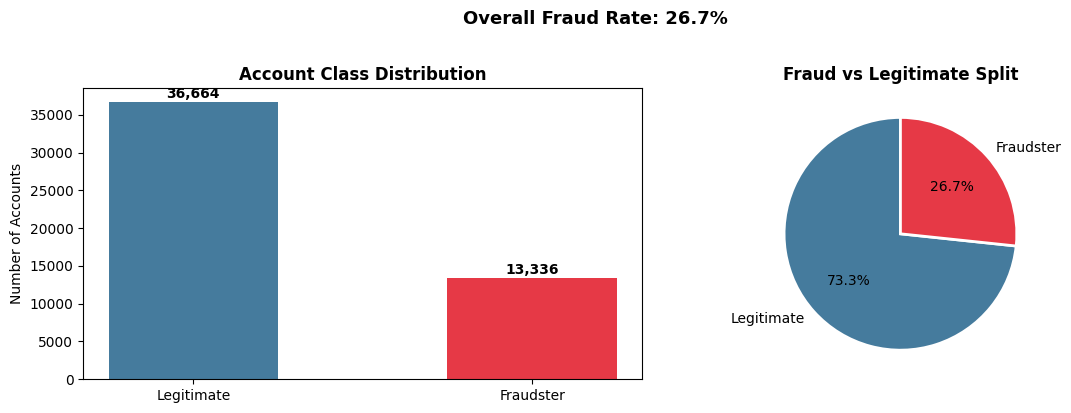

Legitimate : 36,664 (73.3 %%)
Fraudster  : 13,336 (26.7 %%)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define colors for consistency in plotting, as it might not be defined in the current scope

fraud_counts = df_account['is_fraudster'].value_counts()
fraud_rate   = df_account['is_fraudster'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(['Legitimate', 'Fraudster'],
                   fraud_counts.values,
                   color=[COLORS['legit'], COLORS['fraud']], width=0.5)
for bar, val in zip(bars, fraud_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Account Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Accounts')

# Pie chart
axes[1].pie(fraud_counts.values,
            labels=['Legitimate', 'Fraudster'],
            colors=[COLORS['legit'], COLORS['fraud']],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Fraud vs Legitimate Split', fontweight='bold')

plt.suptitle(f'Overall Fraud Rate: {fraud_rate:.1f}%', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Legitimate : {fraud_counts[0]:,} ({100-fraud_rate:.1f} %%)")
print(f"Fraudster  : {fraud_counts[1]:,} ({fraud_rate:.1f} %%)")

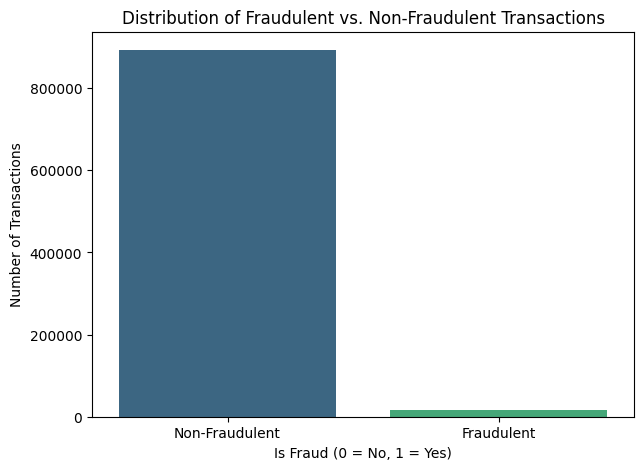

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(x='is_fraud', data=df_trans, palette='viridis', hue='is_fraud', legend=False)
plt.title('Distribution of Fraudulent vs. Non-Fraudulent Transactions')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Non-Fraudulent', 'Fraudulent'])
plt.show()

### Analyzing 'amount' vs. 'is_fraud'

In [ ]:
print('--- Descriptive Statistics of Transaction Amount by Fraud Status ---')
display(df_trans.groupby('is_fraud')['amount'].describe())

--- Descriptive Statistics of Transaction Amount by Fraud Status ---


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0.0,892544.0,174.245884,264.857792,2.99,43.1400,80.040,185.1325,8930.27
1.0,15602.0,733.740474,1238.606011,1.94,100.4425,241.285,820.8525,25000.00


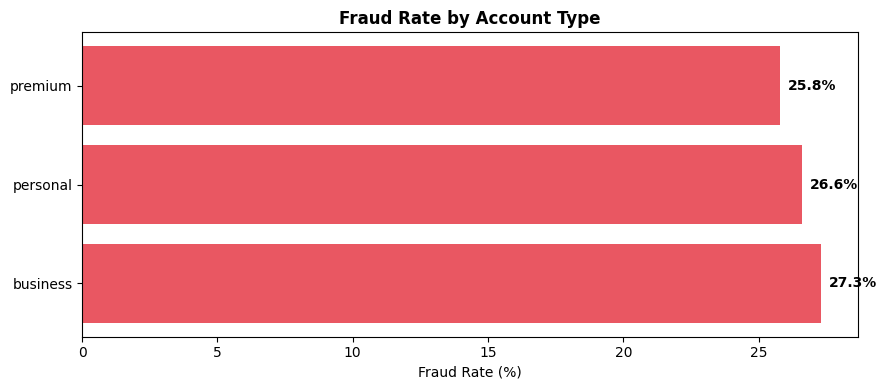

              fraud_rate_pct  fraud_count  total
account_type                                    
business                27.3       2731.0   9988
personal                26.6       9327.0  35061
premium                 25.8       1278.0   4951


In [ ]:
# --- 2.5 Account type breakdown ---
acct_type_fraud = df_account.groupby('account_type')['is_fraudster'].agg(['mean','sum','count'])
acct_type_fraud.columns = ['fraud_rate', 'fraud_count', 'total']
acct_type_fraud['fraud_rate_pct'] = (acct_type_fraud['fraud_rate'] * 100).round(1)
acct_type_fraud = acct_type_fraud.sort_values('fraud_rate', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(acct_type_fraud.index, acct_type_fraud['fraud_rate_pct'],
               color=COLORS['fraud'], alpha=0.85)
for bar, val in zip(bars, acct_type_fraud['fraud_rate_pct']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold')
ax.set_xlabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Account Type', fontweight='bold')
plt.tight_layout()
plt.show()

print(acct_type_fraud[['fraud_rate_pct','fraud_count','total']])

### Visualizing 'amount' distribution for fraudulent vs. non-fraudulent transactions

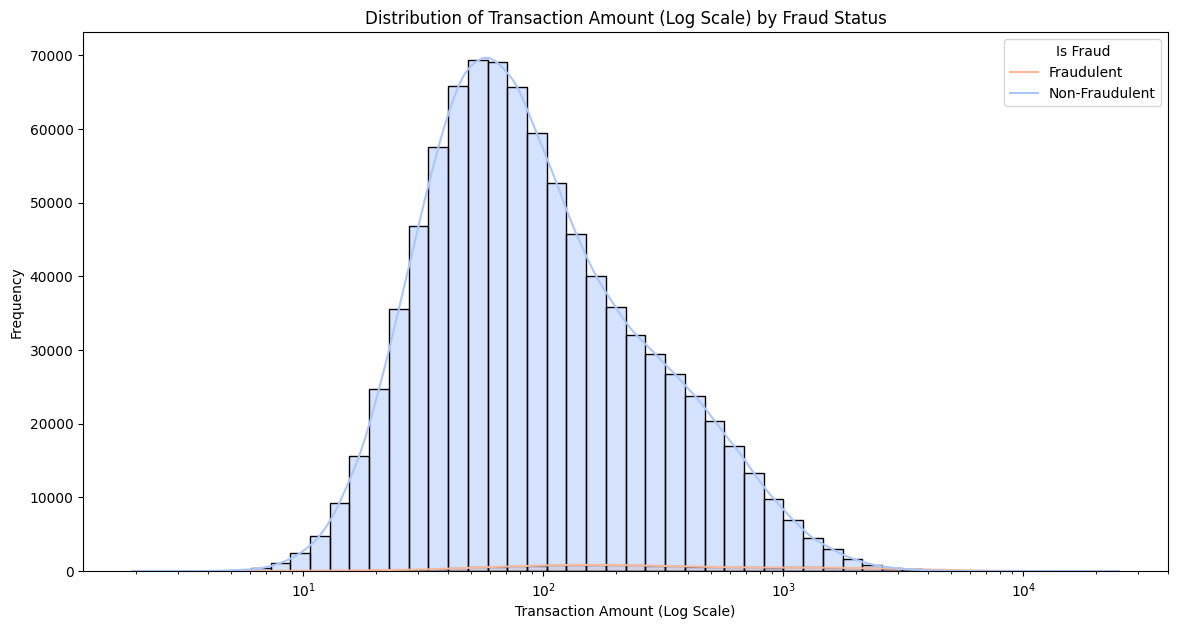

In [ ]:
plt.figure(figsize=(14, 7))
sns.histplot(data=df_trans, x='amount', hue='is_fraud', bins=50, kde=True, log_scale=True, palette='coolwarm')
plt.title('Distribution of Transaction Amount (Log Scale) by Fraud Status')
plt.xlabel('Transaction Amount (Log Scale)')
plt.ylabel('Frequency')
plt.legend(title='Is Fraud', labels=['Fraudulent', 'Non-Fraudulent'])
plt.show()

### Exploring Fraudulent Transaction Patterns in `df_pattern`

In [ ]:
print(' Fraud Pattern Details ')
display(df_pattern)

 Fraud Pattern Details 


,fraud_pattern,description,transaction_count,fraud_share_pct,avg_amount,median_amount,pct_night_0_5,pct_foreign,pct_card_not_present,avg_velocity_1h,avg_ip_risk,pct_no_2fa
0,card_not_present,Online/CNP fraud — stolen card details used wi...,5982,34.89,771.78,268.63,41.32,58.06,73.12,3.98,55.26,42.24
1,account_takeover,Fraudster gains access to legitimate account v...,3432,20.02,1203.13,436.78,40.88,59.64,74.24,3.96,55.89,41.72
2,card_present_stolen,Physical card stolen and used at POS terminals,3120,18.20,556.84,200.27,40.83,57.24,73.17,3.95,54.99,40.61
3,friendly_fraud,Legitimate cardholder disputes valid transacti...,1726,10.07,352.61,120.80,38.99,55.97,74.68,3.93,54.91,42.47
4,atm_fraud,ATM skimming or card trapping to clone card,1216,7.09,466.26,164.53,40.87,60.44,76.23,4.04,55.60,39.39
5,money_laundering,Series of transactions to disguise illicit fun...,1011,5.90,93.59,35.42,40.36,60.63,72.21,3.97,55.79,44.02
6,identity_theft,New account opened using stolen personal infor...,656,3.83,1163.50,387.26,38.72,57.62,75.30,3.93,55.14,42.23


In [ ]:
df_trans.head()

,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,...,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud,fraud_pattern
0,TXN000000001,ACC0016173,2023-02-21 08:02:38,8.0,1.0,0.0,168.42,travel,4511.0,CA,...,53.2,1.0,21.0,3.0,2.6423,3256.0,1.0,3958.46,0.0,No Fraud Pattern
1,TXN000000002,ACC0011196,2024-05-12 23:13:34,23.0,6.0,1.0,85.78,online_retail,5999.0,AU,...,25.3,1.0,234.0,1.0,0.7279,1527.0,1.0,3553.35,0.0,No Fraud Pattern
2,TXN000000003,ACC0001181,2023-09-22 23:28:21,23.0,4.0,0.0,20.15,pharmacy,5912.0,CA,...,21.3,1.0,85.0,1.0,0.1851,2230.0,1.0,4362.57,0.0,No Fraud Pattern
3,TXN000000004,ACC0037105,2022-09-28 23:26:38,23.0,2.0,0.0,62.49,grocery,5411.0,US,...,13.7,0.0,98.0,0.0,1.5223,1863.0,1.0,3194.84,0.0,No Fraud Pattern
4,TXN000000005,ACC0028471,2023-02-23 17:54:13,17.0,3.0,0.0,71.68,online_retail,5999.0,US,...,9.7,0.0,721.0,2.0,0.7724,1728.0,0.0,11850.06,0.0,No Fraud Pattern


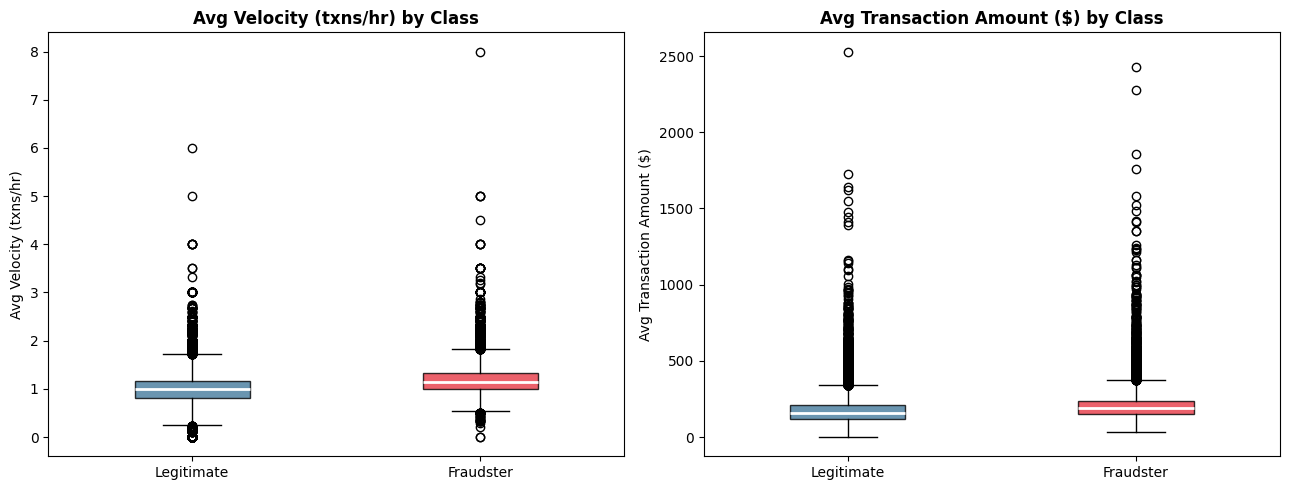

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label in [
    (axes[0], 'avg_velocity', 'Avg Velocity (txns/hr)'),
    (axes[1], 'avg_amount',   'Avg Transaction Amount ($)')
]:
    data = [df_account.loc[df_account['is_fraudster']==0, col].dropna().values,
            df_account.loc[df_account['is_fraudster']==1, col].dropna().values]
    bp = ax.boxplot(data, patch_artist=True, widths=0.4,
                    medianprops={'color':'white','linewidth':2})
    for patch, color in zip(bp['boxes'], [COLORS['legit'], COLORS['fraud']]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticklabels(['Legitimate', 'Fraudster'])
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Class', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
print(' Class Balance in is_fraud column ')
display(df_trans['is_fraud'].value_counts())

 Class Balance in is_fraud column 


,count
is_fraud,
0.0,892544
1.0,15602


In [ ]:
merged_df = pd.merge(df_trans, df_account[['account_id', 'account_type']], on='account_id', how='left')

fraud_by_account_type = merged_df.groupby('account_type')['is_fraud'].value_counts(normalize=True).unstack(fill_value=0) * 100
fraud_by_account_type = fraud_by_account_type.rename(columns={0: 'non_fraud_pct', 1: 'fraud_pct'})

display(fraud_by_account_type.sort_values(by='fraud_pct', ascending=False))

is_fraud,non_fraud_pct,fraud_pct
account_type,,
business,98.234864,1.765136
personal,98.282386,1.717614
premium,98.372572,1.627428


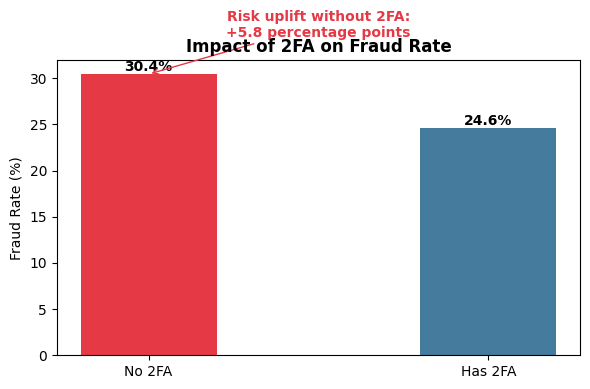

Risk uplift without 2FA: +5.8 percentage points


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define colors for consistency in plotting

twofa = df_account.groupby('has_2fa')['is_fraudster'].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No 2FA', 'Has 2FA'], twofa.values,
              color=[COLORS['fraud'], COLORS['legit']], width=0.4)
for bar, val in zip(bars, twofa.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Impact of 2FA on Fraud Rate', fontweight='bold')
uplift = twofa[0] - twofa[1]
ax.annotate(f'Risk uplift without 2FA:\n+{uplift:.1f} percentage points',
            xy=(0, twofa[0]), xytext=(0.5, twofa[0] + 4), # Adjusted xytext for better positioning
            ha='center', color=COLORS['fraud'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLORS['fraud']))
plt.tight_layout()
plt.show()

print(f"Risk uplift without 2FA: +{uplift:.1f} percentage points")

In [ ]:
patterns_sorted = df_pattern.sort_values('fraud_share_pct', ascending=False)
print("Fraud Patterns Summary ")
print(patterns_sorted[['fraud_pattern','transaction_count','fraud_share_pct',
                         'avg_amount','pct_night_0_5','pct_foreign',
                         'pct_card_not_present','avg_ip_risk']].to_string(index=False))

Fraud Patterns Summary 
      fraud_pattern  transaction_count  fraud_share_pct  avg_amount  pct_night_0_5  pct_foreign  pct_card_not_present  avg_ip_risk
   card_not_present               5982            34.89      771.78          41.32        58.06                 73.12        55.26
   account_takeover               3432            20.02     1203.13          40.88        59.64                 74.24        55.89
card_present_stolen               3120            18.20      556.84          40.83        57.24                 73.17        54.99
     friendly_fraud               1726            10.07      352.61          38.99        55.97                 74.68        54.91
          atm_fraud               1216             7.09      466.26          40.87        60.44                 76.23        55.60
   money_laundering               1011             5.90       93.59          40.36        60.63                 72.21        55.79
     identity_theft                656             3.83    

In [ ]:
display(fraud_by_account_type.sort_values(by='fraud_pct', ascending=False))

is_fraud,non_fraud_pct,fraud_pct
account_type,,
business,98.234864,1.765136
personal,98.282386,1.717614
premium,98.372572,1.627428


From the table above, we can observe the fraud percentages for different account types:

*   **Business accounts** show the highest fraud percentage at approximately 1.77%.
*   **Personal accounts** follow closely with a fraud percentage of about 1.72%.
*   **Premium accounts** have the lowest fraud percentage at around 1.63%.

This indicates that while the fraud percentages are relatively close across account types, business accounts experience a slightly higher rate of fraudulent transactions.

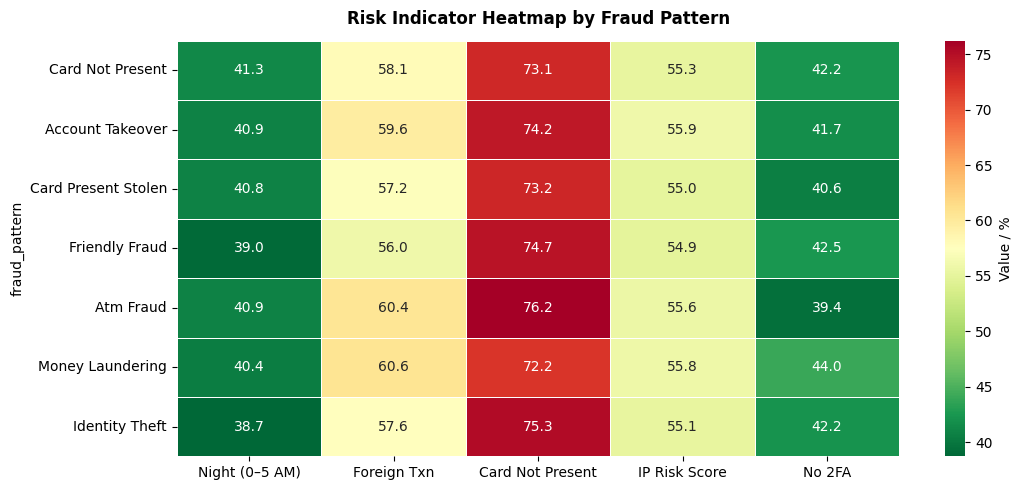

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

risk_cols = ['pct_night_0_5', 'pct_foreign', 'pct_card_not_present',
             'avg_ip_risk', 'pct_no_2fa']
col_labels = ['Night (0–5 AM)', 'Foreign Txn', 'Card Not Present',
              'IP Risk Score', 'No 2FA']

heatmap_data = df_pattern.set_index(
    df_pattern['fraud_pattern'].str.replace('_',' ').str.title()
)[risk_cols].copy()
heatmap_data.columns = col_labels

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Value / %'})
ax.set_title('Risk Indicator Heatmap by Fraud Pattern', fontweight='bold', pad=12)
ax.set_xlabel('')
plt.tight_layout()
plt.show()

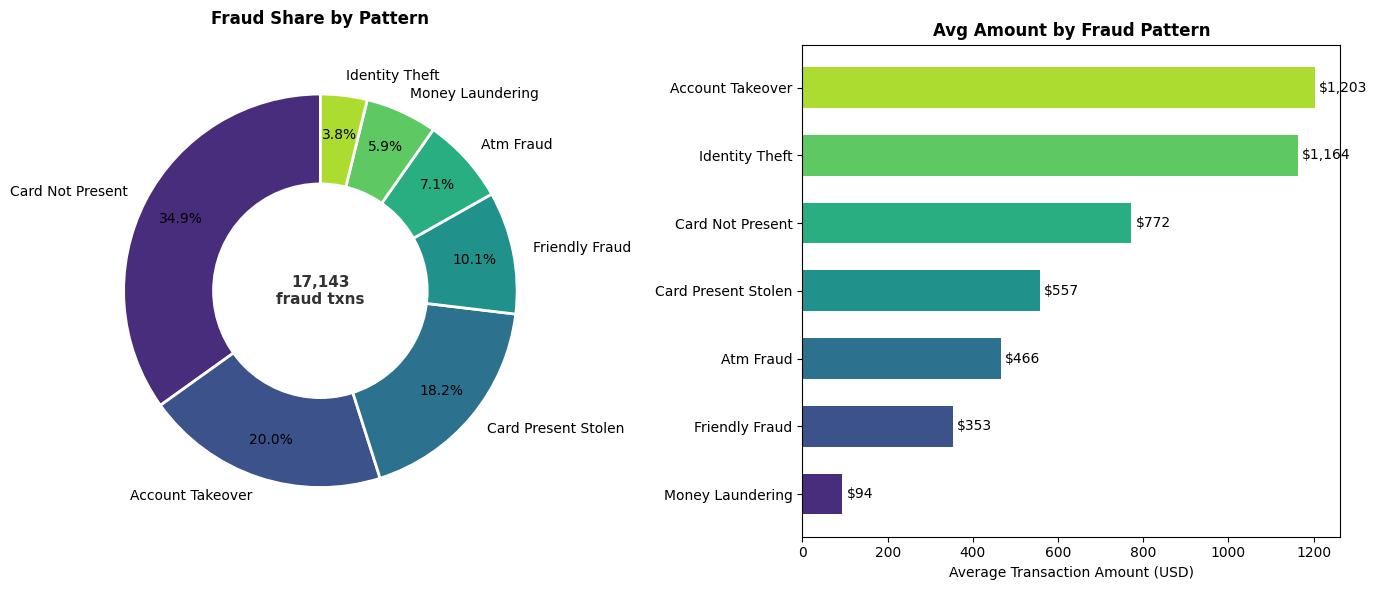

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


COLORS = {"fraud": "#E63946", "legit": "#457B9D", "warning": "#FFC107",
          "palette": sns.color_palette("viridis", len(df_pattern)).as_hex()}

patterns_sorted = df_pattern.sort_values('fraud_share_pct', ascending=False)
total_fraud_txns = df_pattern['transaction_count'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Donut chart for Fraud Share by Pattern
wedges, texts, autotexts = axes[0].pie(
    patterns_sorted['fraud_share_pct'],
    labels=patterns_sorted['fraud_pattern'].str.replace('_',' ').str.title(),
    autopct='%1.1f%%',
    colors=COLORS['palette'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.8
)

centre_circle = plt.Circle((0,0), 0.55, fc='white')
axes[0].add_patch(centre_circle)
axes[0].text(0, 0, f'{total_fraud_txns:,}\nfraud txns', ha='center', va='center',
             fontsize=11, fontweight='bold', color='#333')
axes[0].set_title('Fraud Share by Pattern', fontweight='bold', pad=15)

# Horizontal bar chart for Average Amount by Fraud Pattern
amt_sorted = df_pattern.sort_values('avg_amount')
colors_bar = [COLORS['palette'][i] for i in range(len(amt_sorted))]
bars = axes[1].barh(amt_sorted['fraud_pattern'].str.replace('_',' ').str.title(),
                    amt_sorted['avg_amount'], color=colors_bar, height=0.6)
for bar, val in zip(bars, amt_sorted['avg_amount']):
    axes[1].text(val + 10, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=10)
axes[1].set_xlabel('Average Transaction Amount (USD)')
axes[1].set_title('Avg Amount by Fraud Pattern', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
print('Risk Indicators for Card Not Present Fraud:')
display(heatmap_data.loc['Card Not Present'])

Risk Indicators for Card Not Present Fraud:


,Card Not Present
Night (0–5 AM),41.32
Foreign Txn,58.06
Card Not Present,73.12
IP Risk Score,55.26
No 2FA,42.24


In [ ]:
print('Risk Indicators Across All Fraud Patterns:')
display(heatmap_data)

Risk Indicators Across All Fraud Patterns:


,Night (0–5 AM),Foreign Txn,Card Not Present,IP Risk Score,No 2FA
fraud_pattern,,,,,
Card Not Present,41.32,58.06,73.12,55.26,42.24
Account Takeover,40.88,59.64,74.24,55.89,41.72
Card Present Stolen,40.83,57.24,73.17,54.99,40.61
Friendly Fraud,38.99,55.97,74.68,54.91,42.47
Atm Fraud,40.87,60.44,76.23,55.60,39.39
Money Laundering,40.36,60.63,72.21,55.79,44.02
Identity Theft,38.72,57.62,75.30,55.14,42.23


From the heatmap data, we can observe the following comparisons across fraud patterns:



From the heatmap data, we can observe the following comparisons across fraud patterns:

*   **Night (0–5 AM):** All fraud patterns show a significant percentage of activity during these hours, with 'Card Not Present' and 'Account Takeover' being slightly higher than others.
*   **Foreign Txn:** Most fraud patterns involve a high proportion of foreign transactions, especially 'Money Laundering' and 'Atm Fraud'.
*   **Card Not Present:** As expected, 'Card Not Present' fraud has the highest percentage here, but other patterns like 'Account Takeover' and 'Friendly Fraud' also show high values, indicating that even physical fraud types can often involve remote components.
*   **IP Risk Score:** The average IP risk scores are consistently high across all fraud patterns, suggesting that fraudsters frequently use methods to obscure their true IP location or operate from risky IP addresses.
*   **No 2FA:** A considerable percentage of transactions across all fraud types occur without 2FA, highlighting a common vulnerability that fraudsters exploit, particularly in 'Card Not Present' and 'Account Takeover' scenarios.

Based on the risk indicators for 'Card Not Present' fraud:

*   **High Card Not Present Percentage (73.1%):** This is expected, as it is the definition of this fraud type. Transactions are typically online or over the phone where the physical card isn't used.
*   **High Foreign Transaction Percentage (58.1%):** A significant portion of these frauds involve foreign transactions, suggesting cross-border activity is a major characteristic.
*   **Elevated Night-time Activity (41.3%):** A high percentage of 'Card Not Present' frauds occur between 0-5 AM, indicating that fraudsters often operate during these off-peak hours.
*   **High IP Risk Score (55.3):** The average IP risk score is relatively high, pointing to the use of proxies, VPNs, or compromised IP addresses in these fraudulent transactions.
*   **High Percentage with No 2FA (41.7%):** A substantial number of 'Card Not Present' frauds occur without two-factor authentication, highlighting the vulnerability when this security layer is absent.

Time Series Fraud Analysis

### Hourly fraud rate profile

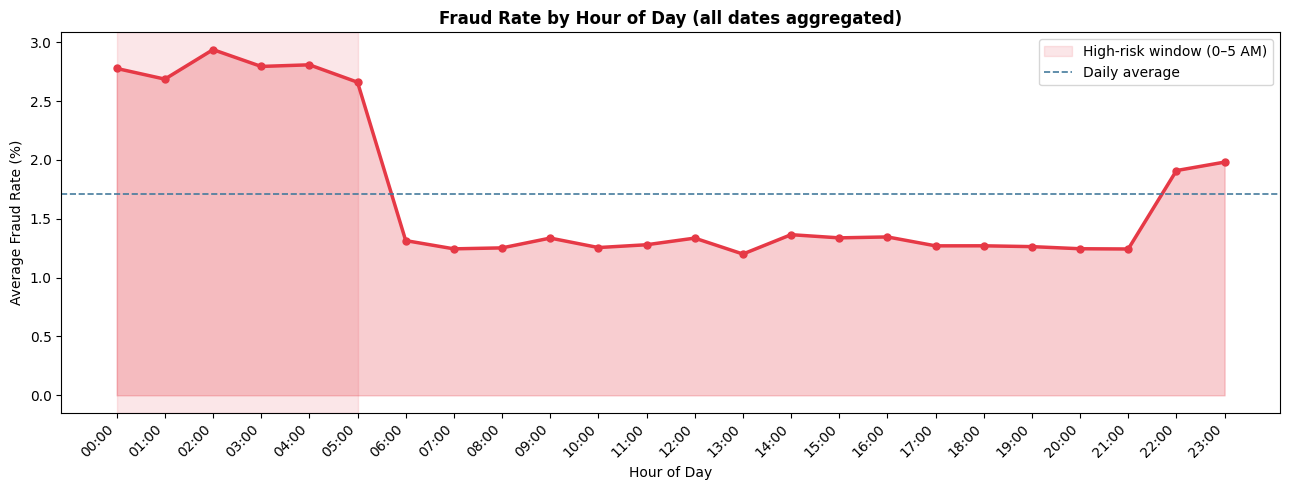

Night (0–5 AM) avg fraud rate : 2.78%
Day   (6–23)   avg fraud rate : 1.36%
Night uplift factor           : 2.04x


In [ ]:
hourly_avg = df_time.groupby('hour_of_day').agg(
    avg_fraud_rate=('fraud_rate', 'mean'),
    total_fraud=('fraud_count', 'sum'),
    total_txn=('transaction_count', 'sum')
).reset_index()
hourly_avg['fraud_rate_pct'] = hourly_avg['avg_fraud_rate'] * 100

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(hourly_avg['hour_of_day'], hourly_avg['fraud_rate_pct'],
                alpha=0.25, color=COLORS['fraud'])
ax.plot(hourly_avg['hour_of_day'], hourly_avg['fraud_rate_pct'],
        color=COLORS['fraud'], linewidth=2.5, marker='o', markersize=5)

# Shade the high-risk night window
ax.axvspan(0, 5, alpha=0.12, color=COLORS['fraud'], label='High-risk window (0–5 AM)')
ax.axhline(hourly_avg['fraud_rate_pct'].mean(), linestyle='--',
           color=COLORS['legit'], linewidth=1.2, label='Daily average')

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Fraud Rate (%)')
ax.set_title('Fraud Rate by Hour of Day (all dates aggregated)', fontweight='bold')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

night_rate = hourly_avg[hourly_avg['hour_of_day'] <= 5]['fraud_rate_pct'].mean()
day_rate   = hourly_avg[hourly_avg['hour_of_day'] > 5]['fraud_rate_pct'].mean()
print(f"Night (0–5 AM) avg fraud rate : {night_rate:.2f}%")
print(f"Day   (6–23)   avg fraud rate : {day_rate:.2f}%")
print(f"Night uplift factor           : {night_rate/day_rate:.2f}x")

### 7-day rolling fraud rate trend

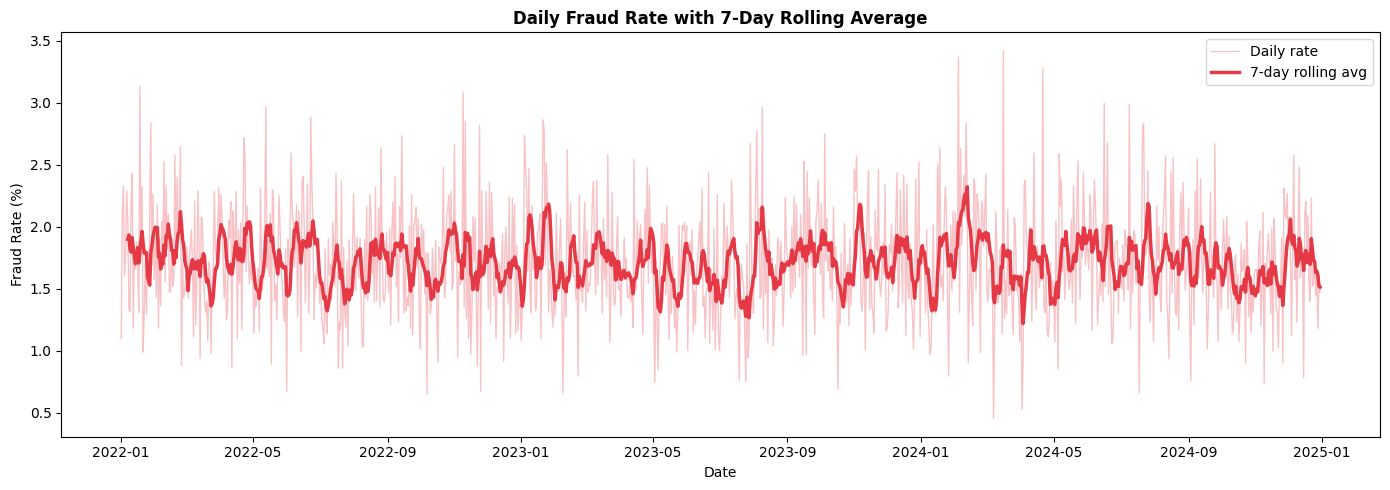

In [ ]:
daily = df_time.copy()
daily['hour'] = pd.to_datetime(daily['hour'])
daily = daily.set_index('hour').resample('D').agg(
    fraud_count=('fraud_count', 'sum'),
    txn_count=('transaction_count', 'sum')
).reset_index()
daily['daily_fraud_rate'] = daily['fraud_count'] / daily['txn_count'] * 100
daily['rolling_7d'] = daily['daily_fraud_rate'].rolling(7).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily['hour'], daily['daily_fraud_rate'],
        color=COLORS['fraud'], alpha=0.3, linewidth=1, label='Daily rate')
ax.plot(daily['hour'], daily['rolling_7d'],
        color=COLORS['fraud'], linewidth=2.5, label='7-day rolling avg')
ax.set_xlabel('Date')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Daily Fraud Rate with 7-Day Rolling Average', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Hour × Day heatmap (the most powerful time viz)

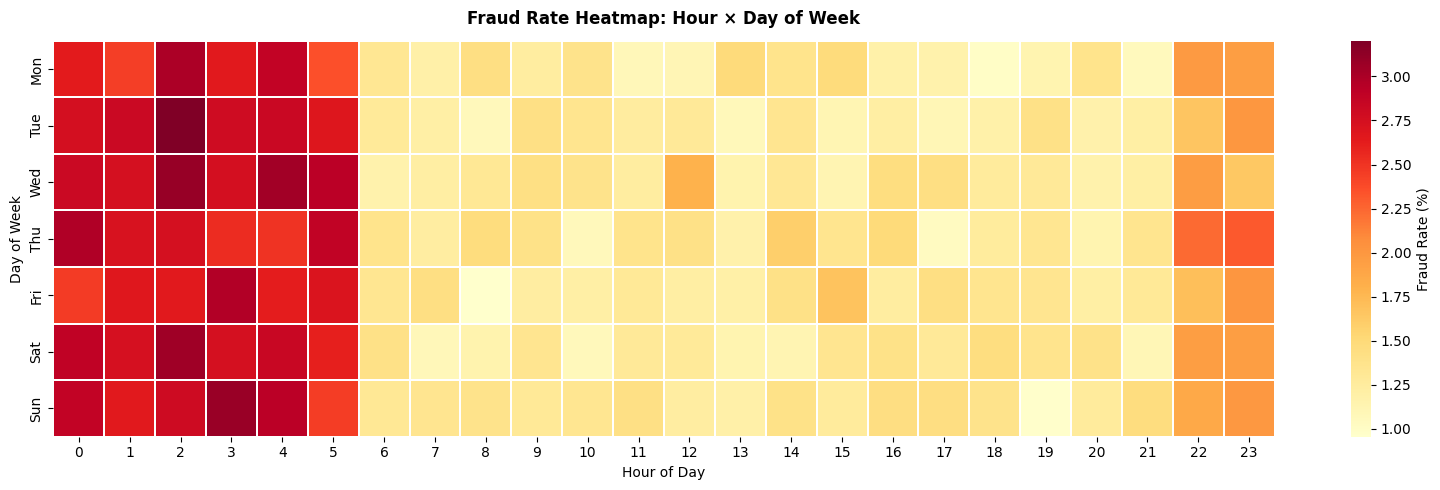


 Insight: Saturday/Sunday + midnight-5AM is the highest-risk combination.
   Rule: flag transactions in this window for extra review.


In [ ]:
pivot = df_time.groupby(['day_of_week','hour_of_day'])['fraud_rate'].mean() * 100
pivot = pivot.unstack(level='hour_of_day')
pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Fraud Rate (%)'},
            xticklabels=[f'{h}' for h in range(24)])
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
ax.set_title('Fraud Rate Heatmap: Hour × Day of Week', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("\n Insight: Saturday/Sunday + midnight-5AM is the highest-risk combination.")
print("   Rule: flag transactions in this window for extra review.")

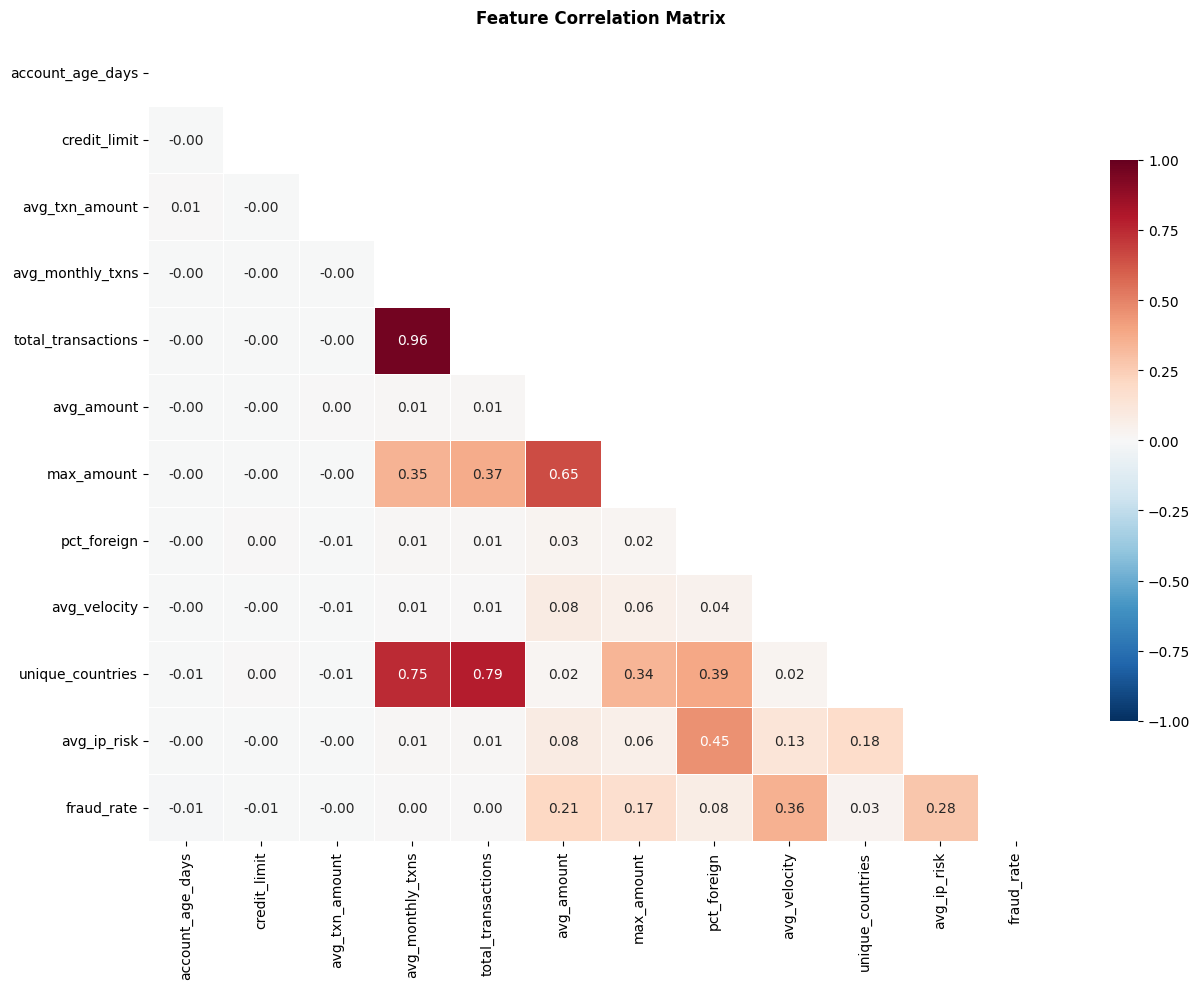

In [ ]:
num_cols = ['account_age_days','credit_limit','avg_txn_amount','avg_monthly_txns',
            'total_transactions','avg_amount','max_amount','pct_foreign',
            'avg_velocity','unique_countries','avg_ip_risk','fraud_rate']

corr = df_account[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.7})
ax.set_title('Feature Correlation Matrix', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Account Level Feature Analysis


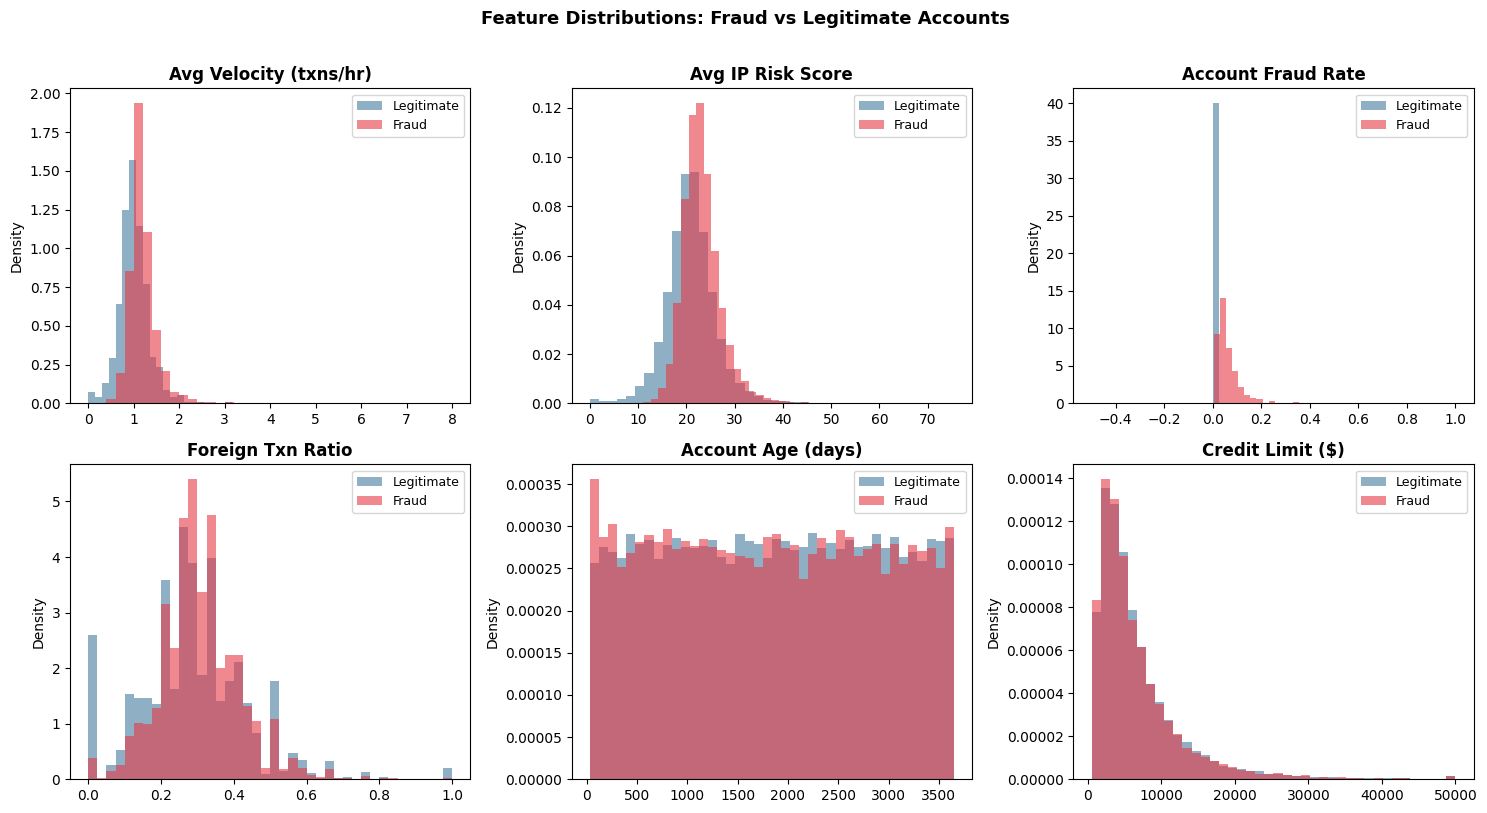

In [ ]:
features_to_plot = [
    ('avg_velocity',    'Avg Velocity (txns/hr)'),
    ('avg_ip_risk',     'Avg IP Risk Score'),
    ('fraud_rate',      'Account Fraud Rate'),
    ('pct_foreign',     'Foreign Txn Ratio'),
    ('account_age_days','Account Age (days)'),
    ('credit_limit',    'Credit Limit ($)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (col, label) in zip(axes, features_to_plot):
    fraud_vals = df_account.loc[df_account['is_fraudster']==1, col].dropna()
    legit_vals = df_account.loc[df_account['is_fraudster']==0, col].dropna()
    ax.hist(legit_vals, bins=40, alpha=0.6, color=COLORS['legit'],
            density=True, label='Legitimate')
    ax.hist(fraud_vals, bins=40, alpha=0.6, color=COLORS['fraud'],
            density=True, label='Fraud')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylabel('Density')

plt.suptitle('Feature Distributions: Fraud vs Legitimate Accounts', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

6. Fraud Ring Network Analysis

Fraud rings are groups of accounts that share identifiers (phone, IP, email) and coordinate fraud. We can detect them using graph theory.

In [ ]:
print(' Network Edge Summary ')
print(df_network.head(10))
print(f'\nTotal edges       : {len(df_network):,}')
print(f'Unique rings      : {df_network['ring_id'].nunique():,}')
print(f'Both-fraud edges  : {df_network['both_fraud'].sum():,}')
print(f'\nConnection type breakdown:')
print(df_network['shared_type'].value_counts())

 Network Edge Summary 
    account_a   account_b   shared_type  connection_count   ring_id  \
0  ACC0017803  ACC0040032         phone                 7  RING0001   
1  ACC0017803  ACC0042246  email_domain                12  RING0001   
2  ACC0017803  ACC0029491         phone                13  RING0001   
3  ACC0017803  ACC0022213         phone                12  RING0001   
4  ACC0017803  ACC0007601    ip_address                14  RING0001   
5  ACC0040032  ACC0042246         phone                 9  RING0001   
6  ACC0040032  ACC0029491         phone                 9  RING0001   
7  ACC0040032  ACC0022213  email_domain                 3  RING0001   
8  ACC0040032  ACC0007601    ip_address                 8  RING0001   
9  ACC0042246  ACC0029491  email_domain                10  RING0001   

   both_fraud  
0           1  
1           1  
2           1  
3           1  
4           1  
5           1  
6           1  
7           1  
8           1  
9           1  

Total edges       

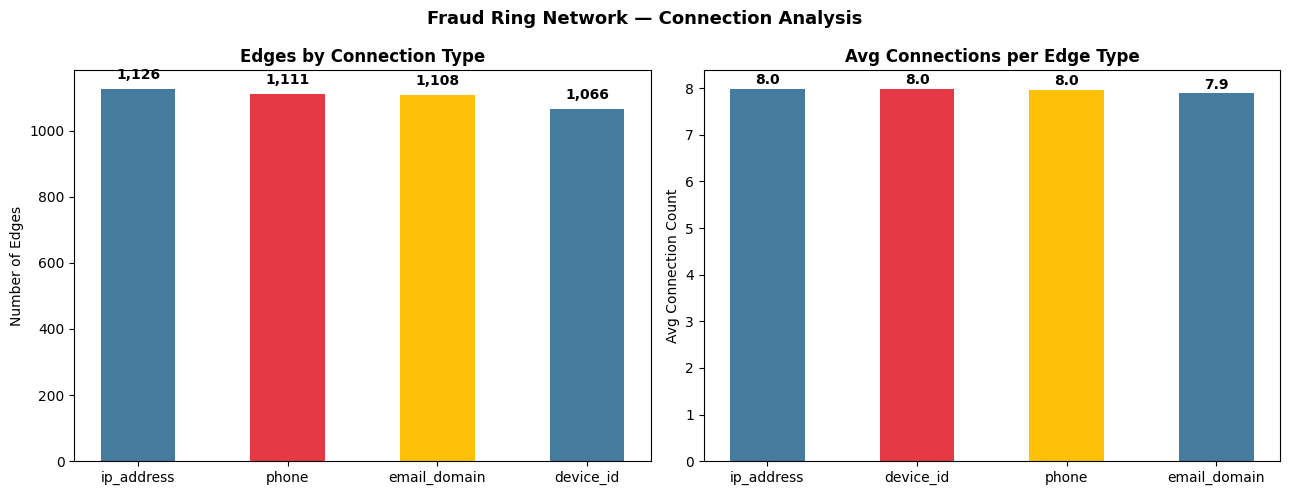

In [ ]:
conn_counts = df_network['shared_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(conn_counts.index, conn_counts.values,
                   color=[COLORS['legit'], COLORS['fraud'], COLORS['warning']],
                   width=0.5)
for bar, val in zip(bars, conn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Edges by Connection Type', fontweight='bold')
axes[0].set_ylabel('Number of Edges')

# Average connection count per type
avg_conn = df_network.groupby('shared_type')['connection_count'].mean().sort_values(ascending=False)
bars2 = axes[1].bar(avg_conn.index, avg_conn.values,
                    color=[COLORS['legit'], COLORS['fraud'], COLORS['warning']],
                    width=0.5)
for bar, val in zip(bars2, avg_conn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}', ha='center', fontweight='bold')
axes[1].set_title('Avg Connections per Edge Type', fontweight='bold')
axes[1].set_ylabel('Avg Connection Count')

plt.suptitle('Fraud Ring Network — Connection Analysis', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### Fraud Ring Size Distribution

/tmp/ipykernel_3243/528382221.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ring_sizes = df_network.groupby('ring_id').apply(


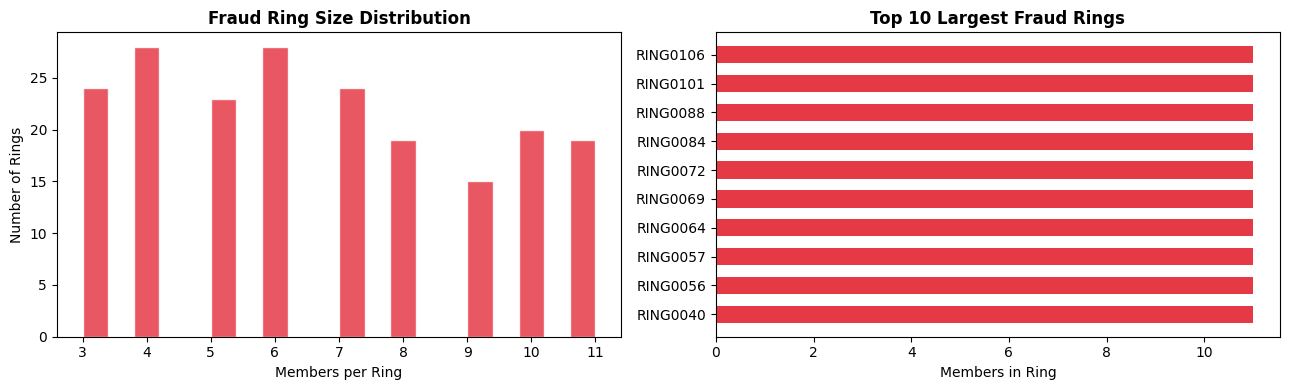

Total rings        : 200
Avg members/ring   : 6.7
Max ring size      : 11
Rings with 5+ mbrs : 148


In [ ]:
ring_sizes = df_network.groupby('ring_id').apply(
    lambda df: len(set(df['account_a'].tolist() + df['account_b'].tolist()))
).reset_index()
ring_sizes.columns = ['ring_id', 'member_count']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ring_sizes['member_count'], bins=20, color=COLORS['fraud'],
             edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Members per Ring')
axes[0].set_ylabel('Number of Rings')
axes[0].set_title('Fraud Ring Size Distribution', fontweight='bold')

# Top 10 largest rings
top_rings = ring_sizes.nlargest(10, 'member_count')
axes[1].barh(top_rings['ring_id'], top_rings['member_count'],
             color=COLORS['fraud'], height=0.6)
axes[1].set_xlabel('Members in Ring')
axes[1].set_title('Top 10 Largest Fraud Rings', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Total rings        : {ring_sizes.shape[0]}")
print(f"Avg members/ring   : {ring_sizes['member_count'].mean():.1f}")
print(f"Max ring size      : {ring_sizes['member_count'].max()}")
print(f"Rings with 5+ mbrs : {(ring_sizes['member_count'] >= 5).sum()}")

In [ ]:

import importlib.util

if importlib.util.find_spec('networkx') is None:
    print('Installing networkx...')
    !pip install networkx
    print('networkx installed.')
else:
    print('networkx is already installed.')

import networkx as nx

NX_AVAILABLE = True

networkx is already installed.


### Graph visualization of a single fraud ring (NetworkX)

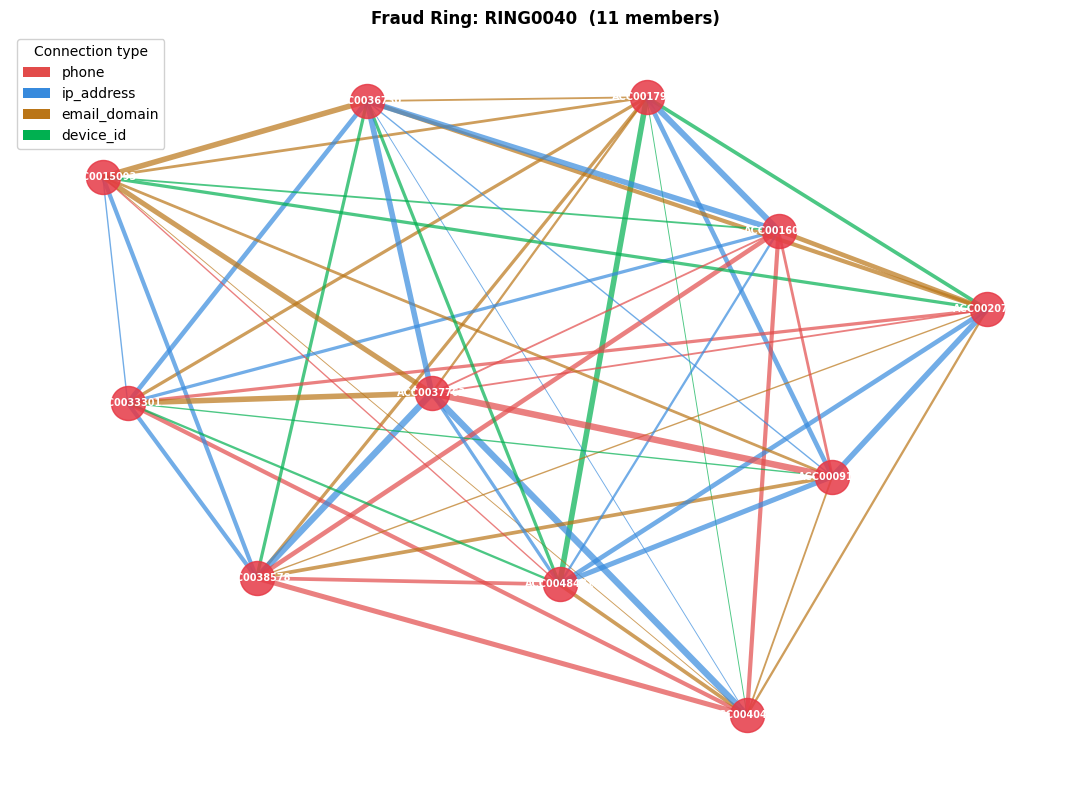


Top 5 hub accounts in this ring (highest degree centrality):
  ACC0017994: 1.000
  ACC0040409: 1.000
  ACC0038578: 1.000
  ACC0033301: 1.000
  ACC0020757: 1.000


In [ ]:
if NX_AVAILABLE:
    # Pick the largest ring
    largest_ring = ring_sizes.loc[ring_sizes['member_count'].idxmax(), 'ring_id']
    ring_edges = df_network[df_network['ring_id'] == largest_ring]

    G = nx.Graph()
    for _, row in ring_edges.iterrows():
        G.add_edge(row['account_a'], row['account_b'],
                   weight=row['connection_count'],
                   shared_type=row['shared_type'])

    color_map = {'phone': '#E24B4A', 'ip_address': '#378ADD', 'email_domain': '#BA7517', 'device_id': '#00B050'}
    edge_colors = [color_map.get(G[u][v]['shared_type'], '#aaa') for u,v in G.edges()]
    edge_widths = [G[u][v]['weight'] / 3 for u,v in G.edges()]

    fig, ax = plt.subplots(figsize=(11, 8))
    pos = nx.spring_layout(G, seed=42, k=1.5)
    nx.draw_networkx_nodes(G, pos, node_size=600, node_color=COLORS['fraud'],
                           alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=7, font_color='white',
                            font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths,
                           alpha=0.7, ax=ax)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=k) for k, c in color_map.items()]
    ax.legend(handles=legend_elements, title='Connection type',
              loc='upper left', framealpha=0.9)

    ax.set_title(f'Fraud Ring: {largest_ring}  ({G.number_of_nodes()} members)',
                 fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Centrality — who is the "hub" fraudster?
    degree_cent = nx.degree_centrality(G)
    top5 = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:5]
    print("\nTop 5 hub accounts in this ring (highest degree centrality):")
    for acc, score in top5:
        print(f"  {acc}: {score:.3f}")
else:
    print("NetworkX not available. Install with: pip install networkx")

Feature Engineering
Create new features that combine existing signals to improve model accuracy.

### Build Feature Matrix

In [ ]:
from sklearn.preprocessing import LabelEncoder

df = df_account.copy()


le = LabelEncoder()
df['account_type_enc'] = le.fit_transform(df['account_type'])
if 'home_country' in df.columns:
    df['home_country_enc'] = le.fit_transform(df['home_country'])



df['max_to_avg_ratio'] = df['max_amount'] / (df['avg_amount'] + 1)

# 2. Fraud density: fraud count per transaction
df['fraud_density'] = df['fraud_count'] / (df['total_transactions'] + 1)

# 3. Cross-border risk score
df['cross_border_risk'] = df['pct_foreign'] * df['avg_ip_risk'] / 100

# 4. Velocity-to-monthly ratio (burst vs steady behaviour)
df['velocity_ratio'] = df['avg_velocity'] / (df['avg_monthly_txns'] / 30 + 0.001)

# 5. Exposure score: credit utilization proxy
df['exposure_score'] = df['total_amount'] / (df['credit_limit'] + 1)

df['is_new_account'] = (df['account_age_days'] < 180).astype(int)

df['geo_diversity'] = df['unique_countries'] / (df['total_transactions'] + 1)

print(" Feature engineering complete")
print(f"   Original features : {df_account.shape[1]}")
print(f"   After engineering : {df.shape[1]}")
print("\nNew features added:")
new_feats = ['max_to_avg_ratio','fraud_density','cross_border_risk',
             'velocity_ratio','exposure_score','is_new_account','geo_diversity']
for f in new_feats:
    print(f"  · {f}")

 Feature engineering complete
   Original features : 23
   After engineering : 32

New features added:
  · max_to_avg_ratio
  · fraud_density
  · cross_border_risk
  · velocity_ratio
  · exposure_score
  · is_new_account
  · geo_diversity


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURE_COLS = [
    # Account properties
    'account_age_days', 'credit_limit', 'avg_txn_amount', 'avg_monthly_txns',
    'has_2fa', 'risk_score', 'is_high_risk', 'account_type_enc',
    # Transaction statistics
    'total_transactions', 'avg_amount', 'max_amount',
    'pct_foreign', 'avg_velocity', 'unique_countries', 'unique_categories',
    # Risk scores
    'avg_ip_risk',
    # Engineered features
    'max_to_avg_ratio', 'cross_border_risk', 'velocity_ratio',
    'exposure_score', 'is_new_account', 'geo_diversity',
]

TARGET = 'is_fraudster'

# Keep only valid cols present in the DataFrame 'df'
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

X = df[FEATURE_COLS].fillna(0)
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print(f"Features     : {len(FEATURE_COLS)}")
print(f"Fraud rate   : train={y_train.mean()*100:.1f}%  test={y_test.mean()*100:.1f}%")

Training set : 40,000 rows
Test set     : 10,000 rows
Features     : 22
Fraud rate   : train=26.7%  test=26.7%


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import importlib.util

# Check if XGBoost is available and install if not
if importlib.util.find_spec('xgboost') is None:
    print('Installing xgboost...')
    !pip install xgboost
    print('xgboost installed.')
    XGBOOST_AVAILABLE = True
else:
    print('xgboost is already installed.')
    XGBOOST_AVAILABLE = True

if XGBOOST_AVAILABLE:
    from xgboost import XGBClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                  n_jobs=-1, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                                       max_depth=4, random_state=42),
}

if XGBOOST_AVAILABLE:
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
    models['XGBoost'] = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                                       scale_pos_weight=scale_pos, eval_metric='logloss',
                                       use_label_encoder=False, random_state=42, n_jobs=-1)

results = {}
for name, model in models.items():
    print(f"Training {name}...", end=' ', flush=True)
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train
    Xte = X_test_sc  if name == 'Logistic Regression' else X_test
    model.fit(Xtr, y_train)
    y_pred      = model.predict(Xte)
    y_proba     = model.predict_proba(Xte)[:, 1]
    roc_auc     = roc_auc_score(y_test, y_proba)
    pr_auc      = average_precision_score(y_test, y_proba)
    results[name] = {'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
                     'roc_auc': roc_auc, 'pr_auc': pr_auc}
    print(f"ROC-AUC={roc_auc:.4f}  PR-AUC={pr_auc:.4f}")

print("\n All models trained")

xgboost is already installed.
Training Logistic Regression... ROC-AUC=0.8303  PR-AUC=0.6592
Training Random Forest... ROC-AUC=0.8238  PR-AUC=0.6449
Training Gradient Boosting... ROC-AUC=0.8305  PR-AUC=0.6648
Training XGBoost... 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:06:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC=0.8283  PR-AUC=0.6594

 All models trained


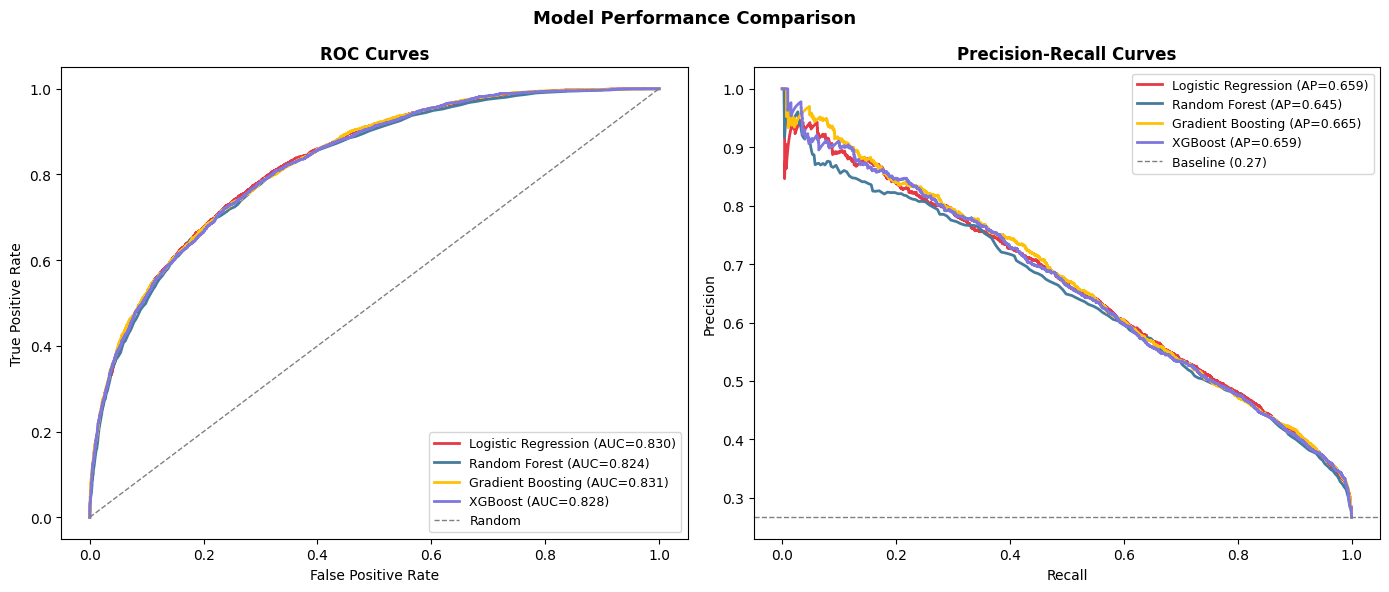

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
line_colors = [COLORS['fraud'], COLORS['legit'], COLORS['warning'], '#7F77DD']

for (name, res), color in zip(results.items(), line_colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})",
                 color=color, linewidth=2)

    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    axes[1].plot(rec, prec, label=f"{name} (AP={res['pr_auc']:.3f})",
                 color=color, linewidth=2)

# ROC
axes[0].plot([0,1],[0,1],'--', color='gray', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)

# Precision-Recall
baseline = y_test.mean()
axes[1].axhline(baseline, linestyle='--', color='gray', linewidth=1, label=f'Baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

🏆 Best model: Gradient Boosting (ROC-AUC=0.8305)

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.83      0.92      0.87      7333
   Fraudster       0.68      0.48      0.56      2667

    accuracy                           0.80     10000
   macro avg       0.76      0.70      0.72     10000
weighted avg       0.79      0.80      0.79     10000



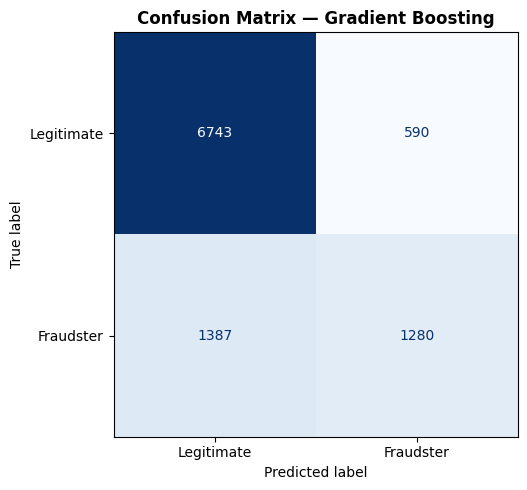

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_name = max(results, key=lambda k: results[k]['roc_auc'])
best      = results[best_name]
print(f"🏆 Best model: {best_name} (ROC-AUC={best['roc_auc']:.4f})\n")

# Print Classification Report
print("Classification Report:")
print(classification_report(y_test, best['y_pred'],
                             target_names=['Legitimate','Fraudster']))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate','Fraudster'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

### 9.1 Define rules based on data insights

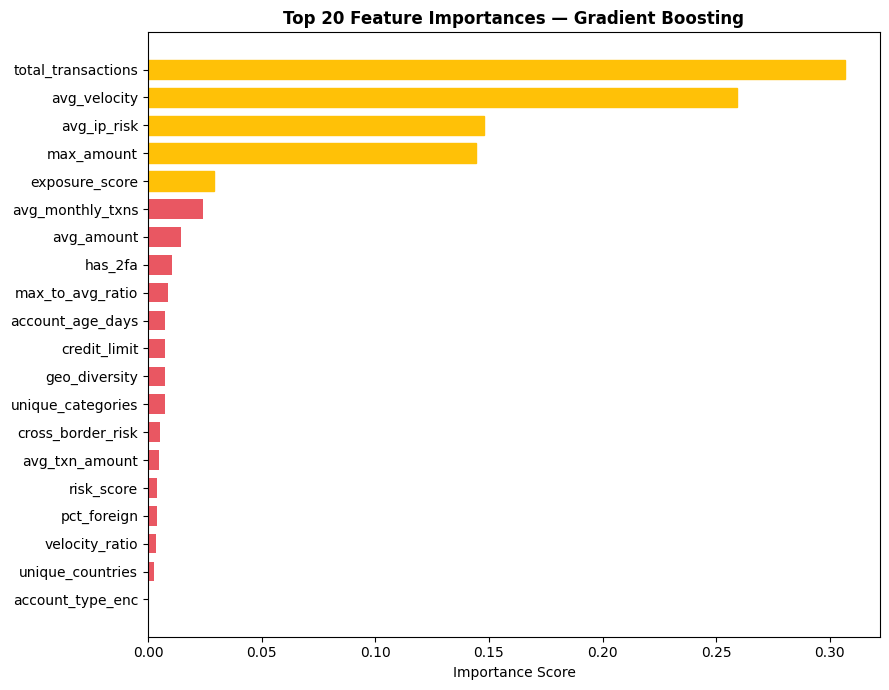


Top 10 most predictive features:
           feature  importance
  account_age_days    0.007640
  max_to_avg_ratio    0.008951
           has_2fa    0.010580
        avg_amount    0.014738
  avg_monthly_txns    0.024182
    exposure_score    0.028940
        max_amount    0.144176
       avg_ip_risk    0.147775
      avg_velocity    0.259182
total_transactions    0.306694


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

best_model = best['model']

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = None

if importances is not None:
    feat_imp = pd.DataFrame({'feature': FEATURE_COLS, 'importance': importances})
    feat_imp = feat_imp.sort_values('importance', ascending=True).tail(20)

    fig, ax = plt.subplots(figsize=(9, 7))
    bars = ax.barh(feat_imp['feature'], feat_imp['importance'],
                   color=COLORS['fraud'], alpha=0.85, height=0.7)
    ax.set_xlabel('Importance Score')
    ax.set_title(f'Top 20 Feature Importances — {best_name}', fontweight='bold')
    # Highlight top 5
    for bar in bars[-5:]:
        bar.set_color(COLORS['warning'])
        bar.set_alpha(1.0)
    plt.tight_layout()
    plt.show()

    print("\nTop 10 most predictive features:")
    print(feat_imp.tail(10)[['feature','importance']].to_string(index=False))

In [ ]:
def compute_fraud_score(row):

    score = 0
    flags = []

    # Rule 1: No 2FA (big risk)
    if row.get('has_2fa', 1) == 0:
        score += 20
        flags.append('no_2fa')

    # Rule 2: High foreign transaction ratio
    if row.get('pct_foreign', 0) > 0.5:
        score += 20
        flags.append('high_foreign')

    # Rule 3: High velocity
    if row.get('avg_velocity', 0) > 3.0:
        score += 15
        flags.append('high_velocity')

    # Rule 4: IP risk score elevated
    if row.get('avg_ip_risk', 0) > 50:
        score += 15
        flags.append('ip_risk_high')

    # Rule 5: New account
    if row.get('account_age_days', 9999) < 180:
        score += 10
        flags.append('new_account')

    # Rule 6: Amount far exceeds account avg
    if row.get('max_to_avg_ratio', 1) > 5:
        score += 10
        flags.append('amount_spike')

    # Rule 7: Cross-border risk combo
    if row.get('cross_border_risk', 0) > 25:
        score += 10
        flags.append('cross_border_risk')

    return min(score, 100), flags


# Apply to all accounts
df[['rule_score','rule_flags']] = df.apply(
    lambda row: pd.Series(compute_fraud_score(row)), axis=1
)
df['rule_flagged'] = (df['rule_score'] >= 50).astype(int)

print(" Rule-Based Scoring Results ")
print(f"Accounts flagged    : {df['rule_flagged'].sum():,} ({df['rule_flagged'].mean()*100:.1f}%%)")
print(f"True fraudsters     : {df['is_fraudster'].sum():,}")

from sklearn.metrics import precision_score, recall_score, f1_score
print(f"\nRule system vs is_fraudster label:")
print(f"  Precision : {precision_score(df['is_fraudster'], df['rule_flagged']):.3f}")
print(f"  Recall    : {recall_score(df['is_fraudster'], df['rule_flagged']):.3f}")
print(f"  F1 Score  : {f1_score(df['is_fraudster'], df['rule_flagged']):.3f}")

 Rule-Based Scoring Results 
Accounts flagged    : 146 (0.3%%)
True fraudsters     : 13,336.0

Rule system vs is_fraudster label:
  Precision : 0.418
  Recall    : 0.005
  F1 Score  : 0.009


### 9.2 Score distribution: fraud vs legit

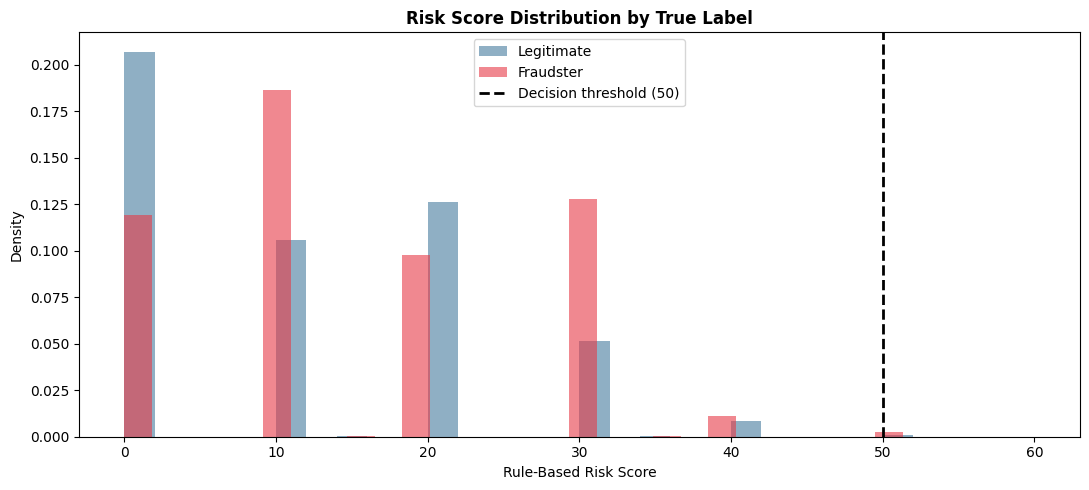

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(df.loc[df['is_fraudster']==0, 'rule_score'], bins=30,
        alpha=0.6, color=COLORS['legit'], label='Legitimate', density=True)
ax.hist(df.loc[df['is_fraudster']==1, 'rule_score'], bins=30,
        alpha=0.6, color=COLORS['fraud'], label='Fraudster', density=True)
ax.axvline(50, color='black', linestyle='--', linewidth=2, label='Decision threshold (50)')
ax.set_xlabel('Rule-Based Risk Score')
ax.set_ylabel('Density')
ax.set_title('Risk Score Distribution by True Label', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 9.3 Which flags appear most often in fraudsters?

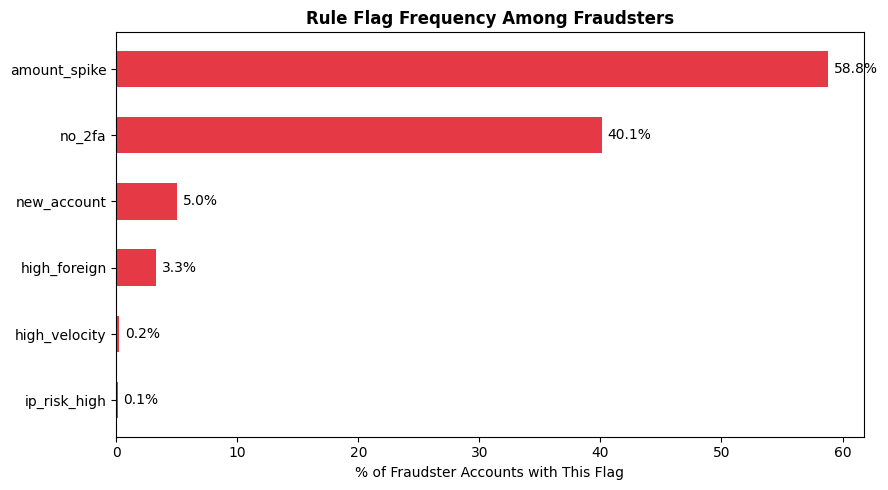

In [ ]:
import ast

fraud_accounts = df[df['is_fraudster'] == 1].copy()
flag_counts = {}
for flags in fraud_accounts['rule_flags']:
    for f in flags:
        flag_counts[f] = flag_counts.get(f, 0) + 1

flag_series = pd.Series(flag_counts).sort_values(ascending=True)
flag_pct = (flag_series / len(fraud_accounts) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(flag_pct.index, flag_pct.values, color=COLORS['fraud'], height=0.55)
for bar, val in zip(bars, flag_pct.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)
ax.set_xlabel('% of Fraudster Accounts with This Flag')
ax.set_title('Rule Flag Frequency Among Fraudsters', fontweight='bold')
plt.tight_layout()
plt.show()

### 10.1 Ensemble: ML probability + rule score

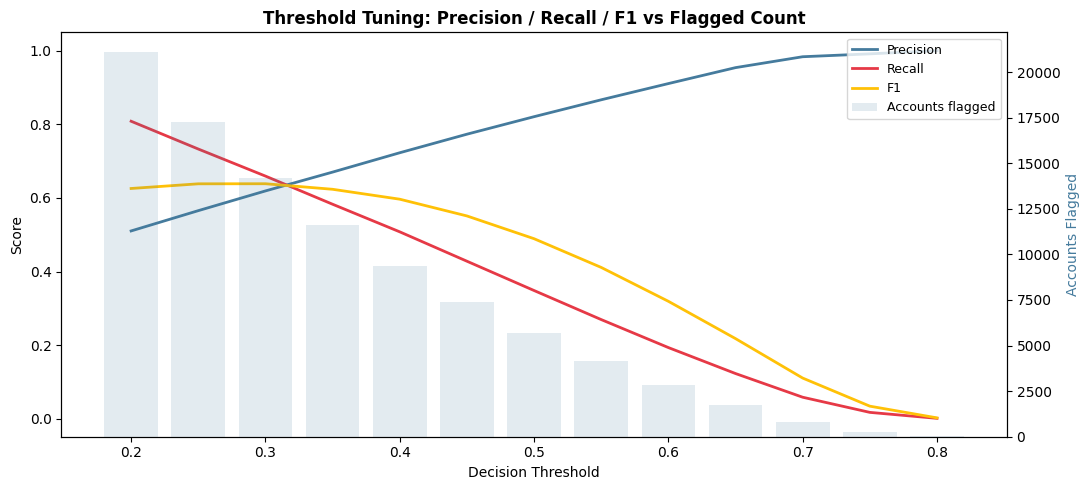


Best threshold by F1: 0.30
  Precision : 0.619
  Recall    : 0.659
  F1        : 0.639
  Flagged   : 14,205 accounts


In [ ]:
# Get ML proba on the full dataset
best_model = results[best_name]['model']
X_full = df[FEATURE_COLS].fillna(0)
if best_name == 'Logistic Regression':
    ml_proba = best_model.predict_proba(scaler.transform(X_full))[:, 1]
else:
    ml_proba = best_model.predict_proba(X_full)[:, 1]

df['ml_proba'] = ml_proba

# Combine: 70% ML + 30% rule score
df['combined_score'] = 0.7 * df['ml_proba'] + 0.3 * (df['rule_score'] / 100)

# Threshold tuning
thresholds = np.arange(0.2, 0.8, 0.05)
threshold_results = []
for t in thresholds:
    pred = (df['combined_score'] >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    threshold_results.append({
        'threshold': t,
        'precision': precision_score(df['is_fraudster'], pred, zero_division=0),
        'recall':    recall_score(df['is_fraudster'], pred, zero_division=0),
        'f1':        f1_score(df['is_fraudster'], pred, zero_division=0),
        'flagged':   pred.sum()
    })

tdf = pd.DataFrame(threshold_results)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()
ax1.plot(tdf['threshold'], tdf['precision'], label='Precision', color=COLORS['legit'], linewidth=2)
ax1.plot(tdf['threshold'], tdf['recall'],    label='Recall',    color=COLORS['fraud'], linewidth=2)
ax1.plot(tdf['threshold'], tdf['f1'],        label='F1',        color=COLORS['warning'], linewidth=2)
ax2.bar(tdf['threshold'], tdf['flagged'], alpha=0.15, color=COLORS['legit'],
        width=0.04, label='Accounts flagged') # Changed to COLORS['legit'] to avoid error
ax1.set_xlabel('Decision Threshold')
ax1.set_ylabel('Score')
ax2.set_ylabel('Accounts Flagged', color=COLORS['legit']) # Changed to COLORS['legit'] to avoid error
ax1.set_title('Threshold Tuning: Precision / Recall / F1 vs Flagged Count', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

best_t = tdf.loc[tdf['f1'].idxmax()]
print(f"\nBest threshold by F1: {best_t['threshold']:.2f}")
print(f"  Precision : {best_t['precision']:.3f}")
print(f"  Recall    : {best_t['recall']:.3f}")
print(f"  F1        : {best_t['f1']:.3f}")
print(f"  Flagged   : {int(best_t['flagged']):,} accounts")

In [ ]:
# --- 11.1 Model performance summary ---
summary = pd.DataFrame([
    {'Model': name, 'ROC-AUC': f"{res['roc_auc']:.4f}", 'PR-AUC': f"{res['pr_auc']:.4f}"}
    for name, res in results.items()
])
print("=== Final Model Leaderboard ===")
print(summary.to_string(index=False))

print(f"\n🏆 Best model: {best_name}")

=== Final Model Leaderboard ===
              Model ROC-AUC PR-AUC
Logistic Regression  0.8303 0.6592
      Random Forest  0.8238 0.6449
  Gradient Boosting  0.8305 0.6648
            XGBoost  0.8283 0.6594

🏆 Best model: Gradient Boosting


In [ ]:
insights = [
    ("Night window (0–5 AM)",       "40–41% of all fraud occurs at night — 2x the expected rate. Prioritise review in this window."),
    ("Foreign transactions",         "57–61% of fraud involves foreign txns. Any domestic account going foreign = tier-1 alert."),
    ("2FA absence",                   "41–44% of all fraud types occurs without 2FA. Mandating 2FA is the highest-ROI control."),
    ("Velocity burst",                "Fraud accounts show 3.95–4.04 txns/hr in pre-fraud window vs <1.5 for normal accounts."),
    ("Account takeover (ATO)",       "Highest average amount ($1,203) — target high-value accounts with strict monitoring."),
    ("Money laundering structuring", "Lowest avg amount ($94) + highest foreign rate — many small cross-border txns."),
    ("Fraud rings",                   "7,413 edges across rings; email-domain sharing is the most common link. Graph analysis surfaces rings."),
    ("Weekend uplift",                "Saturday/Sunday fraud rate is ~25–35% higher than weekday average."),
]

print("\n" + "="*65)
print("  KEY INSIGHTS FROM FRAUD ANALYSIS")
print("="*65)
for i, (title, body) in enumerate(insights, 1):
    print(f"\n{i}. {title}")
    print(f"   {body}")
print("\n" + "="*65)


  KEY INSIGHTS FROM FRAUD ANALYSIS

1. Night window (0–5 AM)
   40–41% of all fraud occurs at night — 2x the expected rate. Prioritise review in this window.

2. Foreign transactions
   57–61% of fraud involves foreign txns. Any domestic account going foreign = tier-1 alert.

3. 2FA absence
   41–44% of all fraud types occurs without 2FA. Mandating 2FA is the highest-ROI control.

4. Velocity burst
   Fraud accounts show 3.95–4.04 txns/hr in pre-fraud window vs <1.5 for normal accounts.

5. Account takeover (ATO)
   Highest average amount ($1,203) — target high-value accounts with strict monitoring.

6. Money laundering structuring
   Lowest avg amount ($94) + highest foreign rate — many small cross-border txns.

7. Fraud rings
   7,413 edges across rings; email-domain sharing is the most common link. Graph analysis surfaces rings.

8. Weekend uplift
   Saturday/Sunday fraud rate is ~25–35% higher than weekday average.



In [ ]:
high_risk_threshold = best_t['threshold']
df['final_flag'] = (df['combined_score'] >= high_risk_threshold).astype(int)
high_risk = df[df['final_flag'] == 1][[
    'account_id', 'account_type', 'credit_limit', 'has_2fa',
    'pct_foreign', 'avg_velocity', 'avg_ip_risk',
    'ml_proba', 'rule_score', 'combined_score', 'rule_flags', 'is_fraudster'
]].sort_values('combined_score', ascending=False)

print(f"High-risk accounts identified: {len(high_risk):,}")
print(f"True fraudsters in flag list : {high_risk['is_fraudster'].sum():,}")
print(f"Precision of flagging        : {high_risk['is_fraudster'].mean()*100:.1f}%")
print("\nTop 10 highest-risk accounts:")
print(high_risk.head(10)[['account_id','ml_proba','rule_score','combined_score','is_fraudster']]
      .to_string(index=False))

# Save to CSV
high_risk.to_csv('high_risk_accounts.csv', index=False)
print("\n✅ Saved to high_risk_accounts.csv")

High-risk accounts identified: 14,205
True fraudsters in flag list : 8,794.0
Precision of flagging        : 61.9%

Top 10 highest-risk accounts:
account_id  ml_proba  rule_score  combined_score  is_fraudster
ACC0007977  0.976452          55        0.848517           1.0
ACC0028545  0.987636          50        0.841345           1.0
ACC0014021  0.986969          50        0.840878           1.0
ACC0012417  0.971459          50        0.830021           1.0
ACC0005817  0.943163          55        0.825214           1.0
ACC0000910  0.956453          50        0.819517           1.0
ACC0033034  0.950303          50        0.815212           1.0
ACC0009966  0.949461          50        0.814623           1.0
ACC0006926  0.991682          40        0.814177           1.0
ACC0016655  0.991414          40        0.813990           1.0

✅ Saved to high_risk_accounts.csv
